# Chapter 34 — Telemetry and Wireless Strain Measurement: Cutting the Wire
### *Modern Strain Gage Technology* — Companion Notebook

Cut the wire, and three quantities decide whether the measurement survives the trip through the air: how much signal reaches the receiver, how long the node's battery lasts, and which coupling method fits the geometry.

Companion notebook to Chapter 34 — Telemetry and Wireless Strain Measurement: Cutting the Wire.

Wires are a constraint. In rotating machinery — turbine blades, helicopter rotors, engine shafts — passing a signal from a spinning surface to a stationary instrument requires slip rings, which add noise, wear, and complexity. In distributed structural health monitoring networks — bridges, wind turbine towers, aircraft wings — running wires from hundreds of sensor nodes to a central acquisition point is expensive, mechanically intrusive, and creates its own failure modes. Wireless telemetry eliminates the wire at the cost of power budget, bandwidth, and link reliability.

The *link budget* is the central engineering tool for wireless system design. It starts with the transmitter power, subtracts the free-space path loss (which scales as the square of distance and the square of frequency), and compares the result to the receiver sensitivity. The difference — the *link margin* — determines whether the connection is viable. Every practical wireless installation must be analyzed at the actual operating frequency and distance, with margins for obstacles, multipath fading, and antenna orientation uncertainty.

Battery life determines the deployment lifetime for autonomous sensor nodes. The key parameter is *duty cycle*: the fraction of time the radio and ADC are active. A typical wireless strain node draws 20 mA during active sampling and transmission, and 10 μA in sleep. At 1% duty cycle, average current is 210 μA and a 2000 mAh battery lasts roughly 400 days. At 10% duty cycle, average current rises to 2 mA and life drops to about 41 days. Managing duty cycle is the primary energy conservation tool for any wireless measurement system.

**This notebook demonstrates:**
1. **Free-space path loss vs. distance** — the 433 MHz, 915 MHz, and 2.4 GHz ISM bands compared on a log-distance scale (regenerates Figure 34.6).
2. **Link budget** — received power, link margin, and viability at a chosen operating point (regenerates Figure 34.7).
3. **Battery life vs. duty cycle** — the steep drop in node lifetime as the active-time fraction rises (regenerates Figure 34.8).
4. **Telemetry method decision tree** — the selection logic from rotation and shaft access down to a specific coupling or radio (regenerates Figure 34.2).

In [1]:
# Colab setup: uncomment to install dependencies
# !pip install numpy matplotlib

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Polygon

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# All figures are written here. The book includes these exact files, so the
# filenames must not change.
OUT_DIR = Path("../src/media/ch34")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Physical constants ---
SPEED_OF_LIGHT_M_S = 3.0e8   # speed of light in vacuum (m/s)


def fspl_db(distance_m, freq_MHz):
    """Free-space path loss in dB at a given distance (m) and frequency (MHz).

    FSPL = 20*log10(4*pi*d*f/c). Path loss rises as the square of both distance
    and frequency, so every doubling of either adds about 6 dB. Accepts scalars
    or NumPy arrays for distance and frequency.
    """
    freq_Hz = np.asarray(freq_MHz, dtype=float) * 1e6
    return 20.0 * np.log10(4.0 * np.pi * np.asarray(distance_m, dtype=float) * freq_Hz / SPEED_OF_LIGHT_M_S)

---
## 1 — Free-Space Path Loss: How Signal Strength Degrades with Distance

Free-space path loss (FSPL) is the fundamental limit on wireless communication range in the absence of obstacles, reflections, or atmospheric absorption. The formula is:

FSPL (dB) = 20·log₁₀(d) + 20·log₁₀(f) + 20·log₁₀(4π/c)

where d is distance in meters and f is frequency in Hz. Two design conclusions follow immediately: path loss increases as the square of distance (every doubling of range costs 6 dB), and path loss increases as the square of frequency (shifting from 433 MHz to 2.4 GHz adds 15 dB of loss at the same distance). This is why long-range wireless sensor deployments favor lower ISM frequencies when spectrum is available.

The three ISM bands plotted here — 433 MHz, 915 MHz, and 2.4 GHz — cover the most common choices for wireless strain node radios. At 100 m distance, the path loss difference between 433 MHz and 2.4 GHz is 15 dB: more than enough to determine whether a marginal link is viable. For installations in open fields or large outdoor structures, the lower bands are strongly preferred. For dense indoor networks where range is short and bandwidth matters, 2.4 GHz is more practical.

Real-world links add additional losses beyond FSPL: multipath fading (10–30 dB in cluttered environments), antenna orientation loss (0–3 dB), and connector loss (0.5–2 dB). The link budget in the next cell accounts for these by reducing the effective transmit power or increasing the required margin.

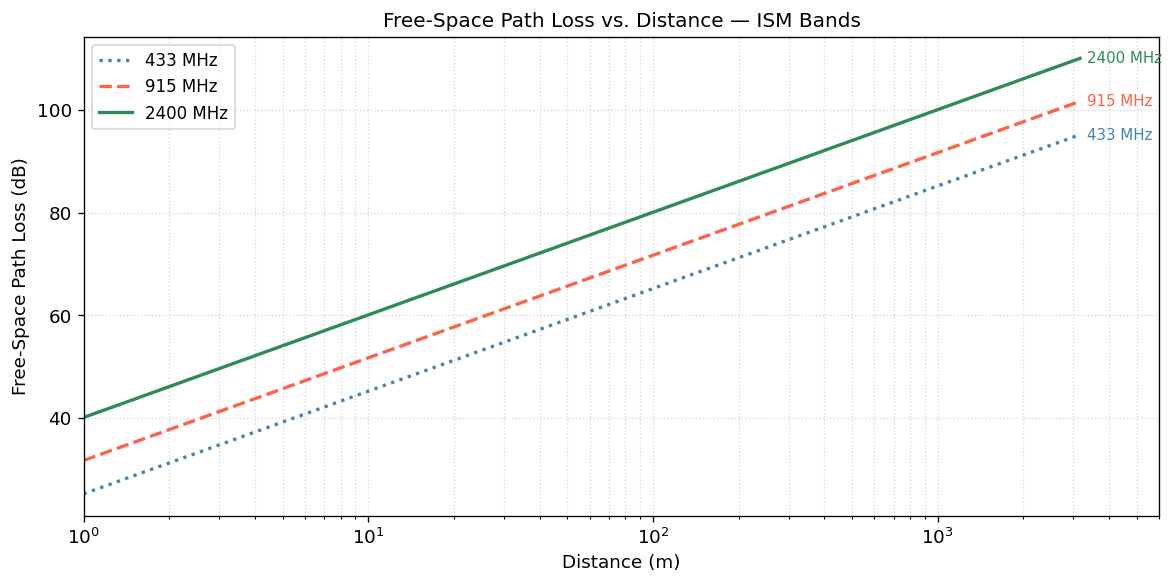

In [2]:
# Figure 34.6 — free-space path loss for the three common ISM bands.
distances = np.logspace(0, 3.5, 500)   # 1 m -> ~3 km
# colour plus line style, and each band labelled at its right-hand end, so the
# three lines stay distinguishable in the black-and-white softcover
bands = [(433, 'steelblue', ':'), (915, 'tomato', '--'), (2400, 'seagreen', '-')]

fig, ax = plt.subplots(figsize=(10, 5))
for freq_MHz, color, ls in bands:
    loss = fspl_db(distances, freq_MHz)
    ax.semilogx(distances, loss, color=color, lw=2, ls=ls, label=f'{freq_MHz} MHz')
    ax.annotate(f'{freq_MHz} MHz', xy=(distances[-1], loss[-1]), xytext=(4, 0),
                textcoords='offset points', va='center', fontsize=9, color=color)

ax.set_xlabel('Distance (m)')
ax.set_ylabel('Free-Space Path Loss (dB)')
ax.set_title('Free-Space Path Loss vs. Distance — ISM Bands')
ax.legend(fontsize=10)
ax.grid(True, which='both', linestyle=':', alpha=0.5)
ax.set_xlim(1, distances[-1] * 1.9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig34_nb1_path_loss_frequency.png', bbox_inches='tight', dpi=300)
plt.show()

## Link Budget Calculator

A **link budget** answers the question: *does enough signal reach the receiver?* The function below plots received power against distance for a chosen frequency and transmit power, then marks the operating point; change its arguments — `freq_MHz`, `distance_m`, `tx_dBm`, `rx_sens` — and re-run the cell to explore other radios and ranges. The title reports the **link margin**: positive means the link is viable, negative means the signal falls below the receiver's sensitivity floor and is lost in the noise.

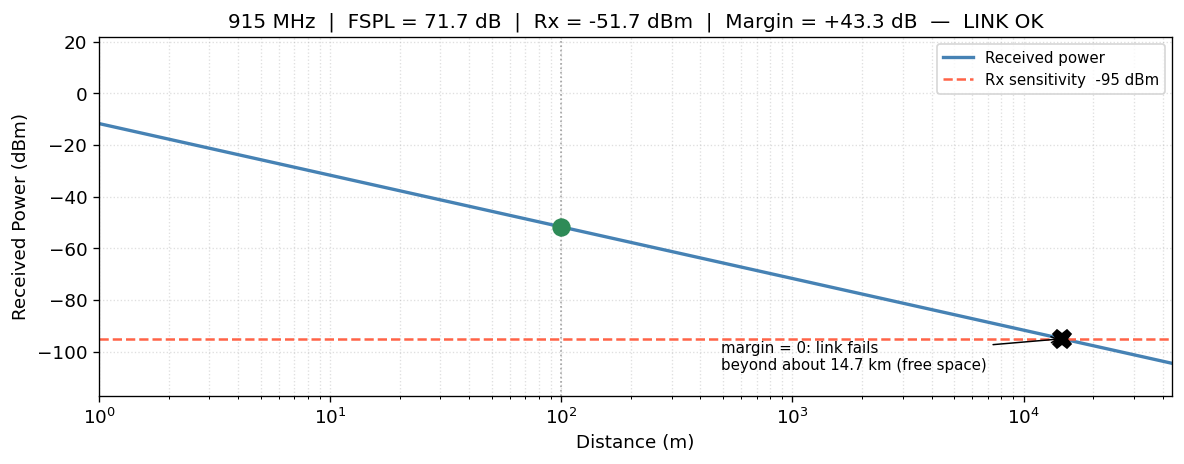

In [3]:
def link_budget(freq_MHz=915, distance_m=100, tx_dBm=20, rx_sens=-95):
    """Plot received power vs. distance and report the link margin at one operating point.

    Received power (dBm) = transmit power - free-space path loss. The link is
    viable while received power stays above the receiver's sensitivity floor;
    the gap between them is the link margin. Change the arguments and re-run to
    test other frequencies, ranges, and radios.
    """
    fspl   = fspl_db(distance_m, freq_MHz)
    rx_pt  = tx_dBm - fspl
    margin = rx_pt - rx_sens
    ok     = margin >= 0

    # Free-space loss grows 20 dB per decade of distance, so the received-power
    # curve meets the sensitivity floor at d_max = distance * 10**(margin/20).
    # Extend the axis past that point so the crossing is actually on the plot.
    d_max  = distance_m * 10 ** (margin / 20)
    d_arr  = np.logspace(0, np.log10(d_max * 3), 500)
    rx_arr = tx_dBm - fspl_db(d_arr, freq_MHz)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.semilogx(d_arr, rx_arr, color='steelblue', lw=2, label='Received power')
    ax.axhline(rx_sens, color='tomato', lw=1.5, linestyle='--',
               label=f'Rx sensitivity  {rx_sens} dBm')
    ax.axvline(distance_m, color='grey', lw=1, linestyle=':', alpha=0.7)
    ax.plot(distance_m, rx_pt, 'o', ms=10, zorder=5,
            color='seagreen' if ok else 'tomato')
    ax.plot(d_max, rx_sens, 'X', ms=11, color='black', zorder=6)
    ax.annotate(f'margin = 0: link fails\nbeyond about {d_max/1000:.1f} km (free space)',
                xy=(d_max, rx_sens), xytext=(d_max / 30, rx_sens - 12),
                fontsize=9, arrowprops=dict(arrowstyle='->', lw=0.9))
    ax.set_xlabel('Distance (m)')
    ax.set_ylabel('Received Power (dBm)')
    ax.set_title(
        f'{freq_MHz} MHz  |  FSPL = {fspl:.1f} dB  |  '
        f'Rx = {rx_pt:.1f} dBm  |  Margin = {margin:+.1f} dB  —  '
        f'{"LINK OK" if ok else "LINK FAILED"}'
    )
    ax.legend(fontsize=9)
    ax.grid(True, which='both', linestyle=':', alpha=0.4)
    ax.set_xlim(1, d_arr[-1])
    ax.set_ylim(rx_sens - 22, tx_dBm + 2)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'fig34_nb2_link_budget.png', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close(fig)

link_budget()

## Battery Life Calculator

Wireless strain nodes spend most of their time asleep. Battery life is dominated by the **duty cycle** — the fraction of time the radio and ADC are active. Even a small increase in duty cycle can shorten life from years to weeks. Change the arguments to `battery_life(...)` below — cell capacity, active and sleep currents, and duty cycle — and re-run to size a node for a given deployment.

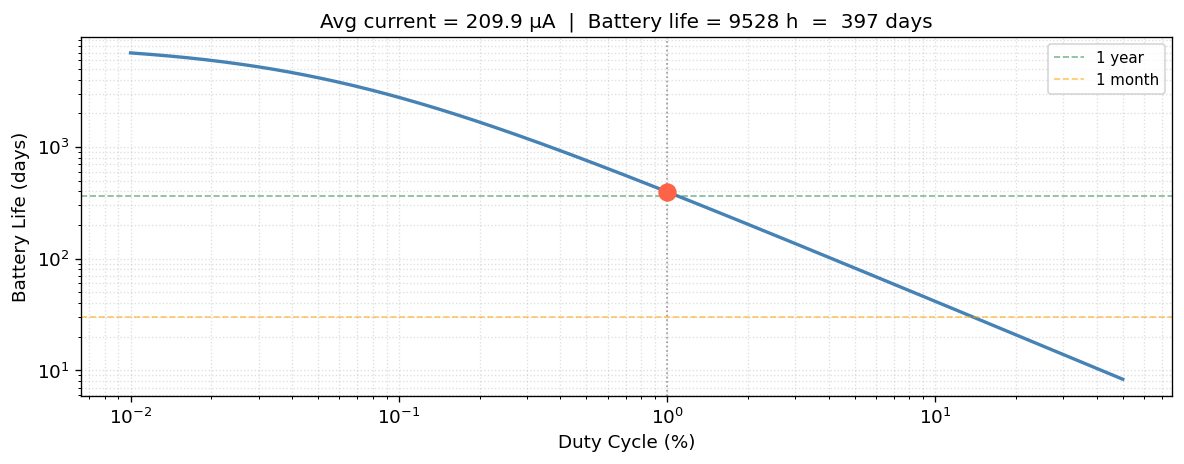

In [4]:
def battery_life(capacity_mAh=2000, i_active_mA=20.0, i_sleep_uA=10.0, duty_pct=1.0):
    """Plot battery life vs. duty cycle and report life at one operating point.

    Average current is the active draw weighted by the duty cycle plus the sleep
    draw for the remaining time; battery life is capacity divided by that
    average. Change the arguments and re-run to size other cells and radios.
    """
    HOURS_PER_DAY = 24
    duty    = duty_pct / 100
    i_avg   = i_active_mA * duty + (i_sleep_uA / 1000) * (1 - duty)   # mA
    life_h  = capacity_mAh / i_avg
    life_d  = life_h / HOURS_PER_DAY

    duty_arr  = np.logspace(-2, np.log10(50), 500) / 100
    i_avg_arr = i_active_mA * duty_arr + (i_sleep_uA / 1000) * (1 - duty_arr)
    life_arr  = capacity_mAh / i_avg_arr / HOURS_PER_DAY

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.loglog(duty_arr * 100, life_arr, color='steelblue', lw=2)
    ax.axvline(duty_pct, color='grey', lw=1, linestyle=':', alpha=0.8)
    ax.plot(duty_pct, life_d, 'o', color='tomato', ms=10, zorder=5)
    ax.axhline(365, color='seagreen', lw=1, linestyle='--', alpha=0.6, label='1 year')
    ax.axhline(30,  color='orange',   lw=1, linestyle='--', alpha=0.6, label='1 month')
    ax.set_xlabel('Duty Cycle (%)')
    ax.set_ylabel('Battery Life (days)')
    ax.set_title(
        f'Avg current = {i_avg*1000:.1f} μA  |  '
        f'Battery life = {life_h:.0f} h  =  {life_d:.0f} days'
    )
    ax.legend(fontsize=9)
    ax.grid(True, which='both', linestyle=':', alpha=0.4)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'fig34_nb3_battery_life.png', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close(fig)

battery_life()

## Telemetry Method Decision Tree

The flow below narrows the choice from the first question down. If a cable can follow the gage, a **direct wired connection** wins. If not, a shaft with room for a ring or coupler takes a **slip ring** when its speed is within the ring's rating, and a **rotary transformer or inductively powered digital telemetry** when it is not (static strain still crosses as modulation of the carrier, at limited bandwidth). Without that access, months of low-rate monitoring point to a duty-cycled **wireless node**; shorter tests branch on bandwidth and channel count to a **battery-powered digital telemetry module** or to **PCM flight-test telemetry**. The diamonds are questions and the rounded boxes outcomes, so the chart reads the same in black and white. Boundaries are practical guidance, not hard limits.

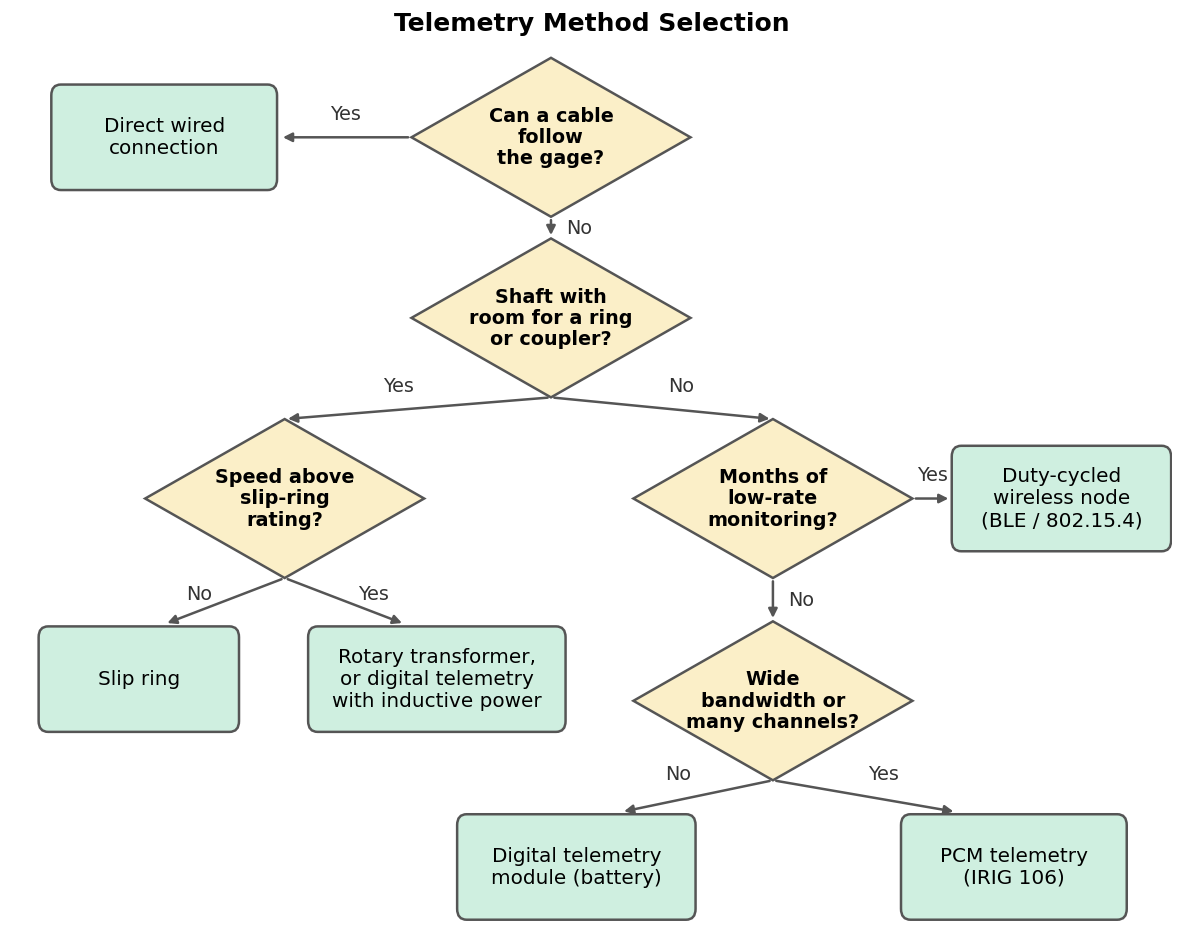

In [5]:
# Figure 34.2 — telemetry-method decision tree.
fig, ax = plt.subplots(figsize=(10, 8.0))
ax.set_xlim(0, 18.3); ax.set_ylim(0.4, 12.6); ax.axis('off')

DCOL, BCOL, EC = '#FBEFC8', '#CFEFE0', '#555555'   # diamond fill, box fill, edge color

def diamond(x, y, text, w=3.4, h=1.7):
    """Draw a decision (diamond) node centered at (x, y) with wrapped text."""
    ax.add_patch(Polygon([(x, y+h/2), (x+w/2, y), (x, y-h/2), (x-w/2, y)],
                         closed=True, facecolor=DCOL, edgecolor=EC, lw=1.5, zorder=2))
    ax.text(x, y, text, ha='center', va='center', fontsize=11.5, fontweight='bold', zorder=3, linespacing=1.15)

def box(x, y, text, w=3.2, h=1.3):
    """Draw an outcome (rounded box) node centered at (x, y) with text."""
    ax.add_patch(FancyBboxPatch((x-w/2, y-h/2), w, h,
                                boxstyle='round,pad=0.08,rounding_size=0.15',
                                facecolor=BCOL, edgecolor=EC, lw=1.5, zorder=2))
    ax.text(x, y, text, ha='center', va='center', fontsize=12, zorder=3)

def arrow(p1, p2, label=None, lx=0.0, ly=0.0):
    """Draw an arrow from p1 to p2 with an optional offset label."""
    ax.annotate('', xy=p2, xytext=p1,
                arrowprops=dict(arrowstyle='-|>', color=EC, lw=1.5), zorder=4)
    if label:
        ax.text((p1[0]+p2[0])/2 + lx, (p1[1]+p2[1])/2 + ly, label,
                ha='center', va='center', fontsize=11.5, color='#333333', zorder=4)

# --- nodes ---
# Box half-height is h/2 + pad = 0.65 + 0.08 = 0.73, so arrows into a box end
# just outside that edge and their heads stay visible above the fill.
DW, DH = 4.4, 2.2                      # diamond size, large enough for print-size text
diamond(8.5, 11.4, 'Can a cable\nfollow\nthe gage?', w=DW, h=DH)
box(2.4, 11.4, 'Direct wired\nconnection', w=3.4)
diamond(8.5, 8.9, 'Shaft with\nroom for a ring\nor coupler?', w=DW, h=DH)
diamond(4.3, 6.4, 'Speed above\nslip-ring\nrating?', w=DW, h=DH)
diamond(12.0, 6.4, 'Months of\nlow-rate\nmonitoring?', w=DW, h=DH)
box(2.0, 3.9, 'Slip ring', w=3.0)
box(6.7, 3.9, 'Rotary transformer,\nor digital telemetry\nwith inductive power', w=3.9)
box(16.55, 6.4, 'Duty-cycled\nwireless node\n(BLE / 802.15.4)', w=3.3)
diamond(12.0, 3.6, 'Wide\nbandwidth or\nmany channels?', w=DW, h=DH)
box(15.8, 1.3, 'PCM telemetry\n(IRIG 106)', w=3.4)
box(8.9, 1.3, 'Digital telemetry\nmodule (battery)', w=3.6)

# --- arrows ---
arrow((6.3, 11.4), (4.22, 11.4), 'Yes', ly=0.32)               # D1 -> wired
arrow((8.5, 10.3), (8.5, 10.0), 'No', lx=0.45)                 # D1 -> D2
arrow((8.5, 7.8), (4.3, 7.5), 'Yes', lx=-0.3, ly=0.3)          # D2 -> D3
arrow((8.5, 7.8), (12.0, 7.5), 'No', lx=0.3, ly=0.3)           # D2 -> D4
arrow((4.3, 5.3), (2.4, 4.66), 'No', lx=-0.4, ly=0.1)          # D3 -> slip
arrow((4.3, 5.3), (6.2, 4.66), 'Yes', lx=0.45, ly=0.1)         # D3 -> rotary
arrow((14.2, 6.4), (14.82, 6.4), 'Yes', ly=0.32)               # D4 -> node
arrow((12.0, 5.3), (12.0, 4.7), 'No', lx=0.45)                 # D4 -> D5
arrow((12.0, 2.5), (14.9, 2.06), 'Yes', lx=0.3, ly=0.3)        # D5 -> PCM
arrow((12.0, 2.5), (9.6, 2.06), 'No', lx=-0.3, ly=0.3)         # D5 -> module

ax.set_title('Telemetry Method Selection', fontsize=15, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig34_nb4_telemetry_decision.png', bbox_inches='tight', dpi=300)
plt.show()

## Where to take this next

These four figures are a starting point. A few concrete extensions, each tied to a concern raised in Chapter 34:

- **Budget the real-world losses, not just FSPL.** Free-space loss is only the floor. As rough planning allowances (typical values, not figures from the chapter), budget something like 10–30 dB for multipath fading, 0–3 dB for antenna misorientation, and 0.5–2 dB for connectors. Add an `extra_loss_dB` argument to `link_budget()` that subtracts these from the received-power curve, then find the transmit power or maximum range that keeps a chosen fade margin (say 10 dB) in hand — the difference between a link that works on the bench and one that works in a cluttered plant.
- **Solve for maximum range instead of reading it off the plot.** Invert `fspl_db` to get the distance at which received power equals the sensitivity floor, and plot maximum range versus frequency across the three ISM bands. This turns the chapter's qualitative claim — lower bands reach farther for the same transmit power — into a curve you can quote.
- **Close the energy-harvesting loop.** The chapter's energy-harvesting section describes microwatt-to-milliwatt budgets that force very low duty cycles. Given a harvested power level, solve for the maximum sustainable duty cycle at which the node never drains its cell, and check it against the SHM example (10 µW sleep, 10 mW for 1 s every 10 minutes ≈ 27 µW average) — the boundary between "battery-free forever" and "battery-limited."